# Supplementary Figure 2: chromosome-free boundary sensitivity

The Figure 2 model is repeated without the persistent chromosomal transposable-element copy. The chromosome-free state space is $T_0,\ldots,T_n$, the lower-boundary $T_0\to T_1$ coefficient is zero in all three configurations, and the primary and chromosome-free variants start from the same internal-state abundance weights. Removing the chromosomal copy also reduces the total TCN entering the antibiotic-protection term by one.


In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault("SIM_RUN_MODE", "production")
%run ./simulation_core.ipynb
plt.rcParams.update(PLOT_STYLE)

MAX_PCN=100
OUTPUT_ROOT, FIGURE_DIR, SOURCE_DIR = make_output_dirs("Supplementary_Figure_2_outputs")
PRIMARY_CONFIGS=standard_configurations(MAX_PCN)
ZERO_CONFIGS=[make_configuration(MAX_PCN, condition=c.condition, kappa_f=c.kappa_f, kappa_b=c.kappa_b,
                                 setting_label="chromosome-free", lower_forward_rate=0.0)
              for c in PRIMARY_CONFIGS]


## Fixed and transient simulations


In [2]:
records=[]
fixed={}
transient={}
for primary, zero in zip(PRIMARY_CONFIGS, ZERO_CONFIGS):
    for phase, duration, init in (
        ("loss", RELAXED_DAYS_PER_CYCLE, fixed_loss_initial_state(MAX_PCN)),
        ("gain", SELECTED_DAYS_PER_CYCLE, fixed_gain_initial_state(MAX_PCN)),
    ):
        p,_,_,_=simulate_phase(MAX_PCN, primary, phase=phase, duration_days=duration,
                               initial_state=init.copy(), record_trajectory=True, chromosomal_copy=1)
        z,_,_,_=simulate_phase(MAX_PCN, zero, phase=phase, duration_days=duration,
                               initial_state=init.copy(), record_trajectory=True, chromosomal_copy=0)
        fixed[(phase,primary.condition,"primary")]=p
        fixed[(phase,primary.condition,"chromosome-free")]=z
    init=periodic_initial_state(MAX_PCN)
    p,_,_=simulate_transient_cycles(MAX_PCN, primary, cycles=TRANSIENT_CYCLES,
                                    initial_state=init.copy(), chromosomal_copy=1)
    z,_,_=simulate_transient_cycles(MAX_PCN, zero, cycles=TRANSIENT_CYCLES,
                                    initial_state=init.copy(), chromosomal_copy=0)
    transient[(primary.condition,"primary")]=p
    transient[(primary.condition,"chromosome-free")]=z


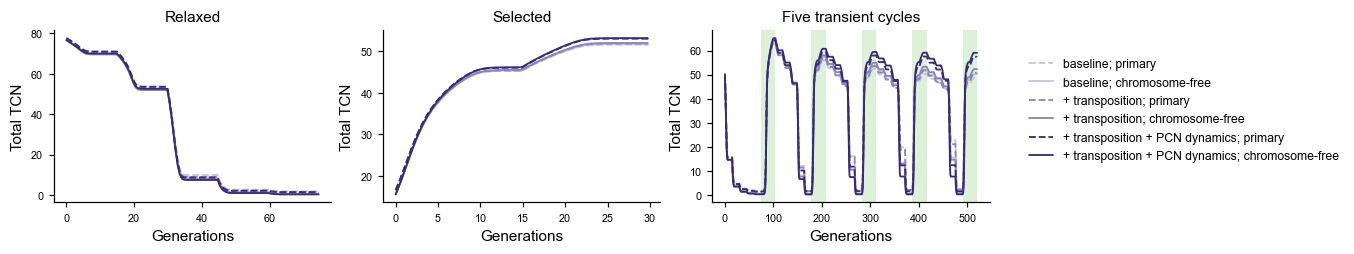

In [16]:
fig, axes=plt.subplots(1,3,figsize=(12.2,2.2),constrained_layout=True)
for ax, phase, title in ((axes[0],"loss","Relaxed"),(axes[1],"gain","Selected")):
    for c in PRIMARY_CONFIGS:
        for variant,ls in (("primary","--"),("chromosome-free","-")):
            d=fixed[(phase,c.condition,variant)]
            ax.plot(d.phase_day*PASSAGE_GENERATIONS,d.TCN_per_density,
                    color=CONDITION_COLORS[c.condition],lw=1.2,ls=ls)
    ax.set_title(title, fontsize = 10); ax.set_xlabel("Generations", fontsize = 10); ax.set_ylabel("Total TCN", fontsize = 10)
for cycle in range(1,TRANSIENT_CYCLES+1):
    start=(cycle-1)*DAYS_PER_CYCLE+RELAXED_DAYS_PER_CYCLE
    axes[2].axvspan(start*PASSAGE_GENERATIONS,(start+SELECTED_DAYS_PER_CYCLE)*PASSAGE_GENERATIONS,
                    color=SELECTION_SHADE,lw=0,zorder=0)
for c in PRIMARY_CONFIGS:
    for variant,ls in (("primary","--"),("chromosome-free","-")):
        d=transient[(c.condition,variant)]
        axes[2].plot(d.Day*PASSAGE_GENERATIONS,d.TCN_per_density,
                     color=CONDITION_COLORS[c.condition],lw=1.2,ls=ls,
                     label=(DISPLAY_LABELS[c.condition]+("; primary" if variant=="primary" else "; chromosome-free")))
axes[2].set_title("Five transient cycles", fontsize = 10); axes[2].set_xlabel("Generations", fontsize = 10); axes[2].set_ylabel("Total TCN", fontsize = 10)
axes[2].legend(
    loc="upper center",
    bbox_to_anchor=(1.7, 0.9),
    frameon=False,
    fontsize=8,
)
save_figure(fig,"Supplementary_Figure_2_chromosome_free",FIGURE_DIR)
plt.show()

source=[]
for (phase,condition,variant),d in fixed.items():
    x=d.copy(); x["analysis"]="fixed"; x["variant"]=variant; source.append(x)
for (condition,variant),d in transient.items():
    x=d.copy(); x["analysis"]="transient"; x["variant"]=variant; source.append(x)
export_table(pd.concat(source,ignore_index=True),"Supplementary_Figure_2_source_data.csv",SOURCE_DIR)
export_table(core_metadata("Supplementary Figure 2"),"Supplementary_Figure_2_run_metadata.csv",SOURCE_DIR)
